In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Task 0: Setup and Data Loading

In [28]:
df = pd.read_csv('/content/Employee data.csv')

df.head()

,id,gender,bdate,educ,jobcat,salary,salbegin,jobtime,prevexp,minority
0,1.0,Male,1952-02-03,15,Manager,57000.0,27000.0,98.0,144.0,No
1,2.0,Male,1958-05-23,16,Clerical,40200.0,18750.0,98.0,36.0,No
2,3.0,Female,1929-07-26,12,Clerical,21450.0,12000.0,98.0,381.0,No
3,4.0,Female,1947-04-15,8,Clerical,21900.0,13200.0,98.0,190.0,No
4,5.0,Male,1955-02-09,15,Clerical,45000.0,21000.0,98.0,138.0,No


In [29]:
print("Shape of Dataset:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(474, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        474 non-null    float64
 1   gender    474 non-null    object 
 2   bdate     473 non-null    object 
 3   educ      474 non-null    int64  
 4   jobcat    474 non-null    object 
 5   salary    474 non-null    float64
 6   salbegin  474 non-null    float64
 7   jobtime   474 non-null    float64
 8   prevexp   474 non-null    object 
 9   minority  474 non-null    object 
dtypes: float64(4), int64(1), object(5)
memory usage: 37.2+ KB
None

Statistical Summary:
               id        educ         salary      salbegin     jobtime
count  474.000000  474.000000     474.000000    474.000000  474.000000
mean   237.500000   13.491561   34419.567511  17016.086498   81.109705
std    136.976275    2.884846   17075.661465   7870.638154   10.060945
min

In [30]:
print(df.isnull().sum())

id          0
gender      0
bdate       1
educ        0
jobcat      0
salary      0
salbegin    0
jobtime     0
prevexp     0
minority    0
dtype: int64


## Task 1: Data Cleaning

In [31]:
df = df.fillna(df.mean(numeric_only=True))

In [32]:
# Remove duplicates
df = df.drop_duplicates()

## Task 2: Data Visualization

In [33]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['salary'] >= lower) & (df['salary'] <= upper)]

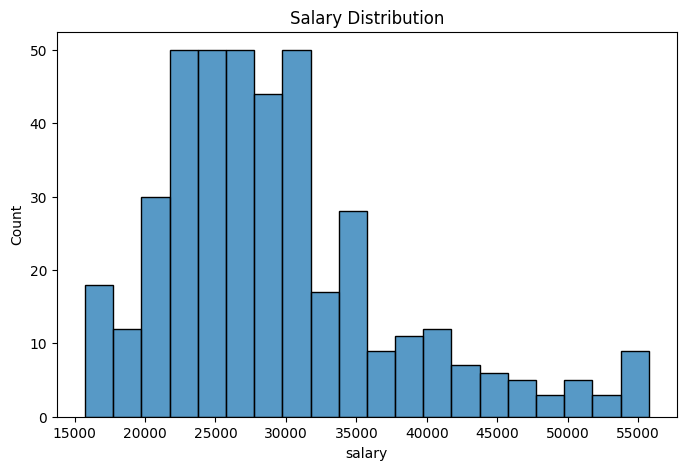

In [34]:
# Visualization 1
plt.figure(figsize=(8,5))
sns.histplot(df['salary'], bins=20)
plt.title("Salary Distribution")
plt.show()


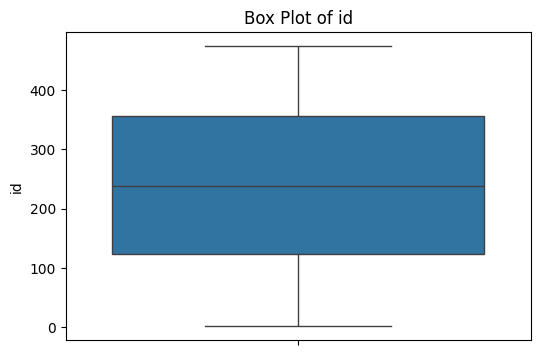

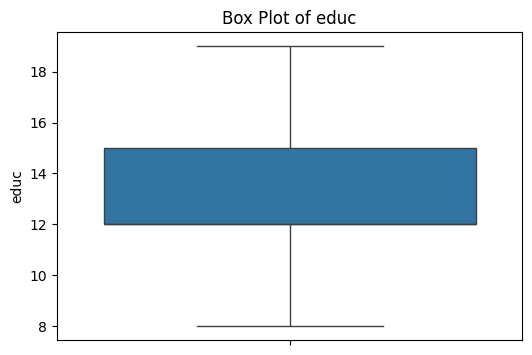

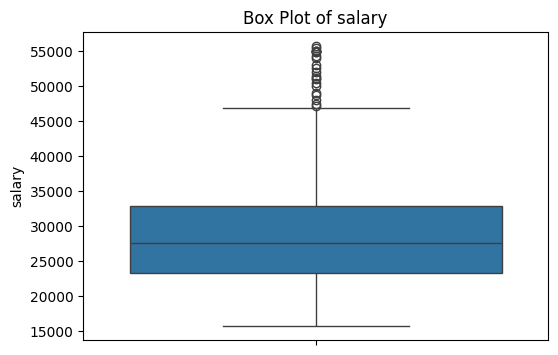

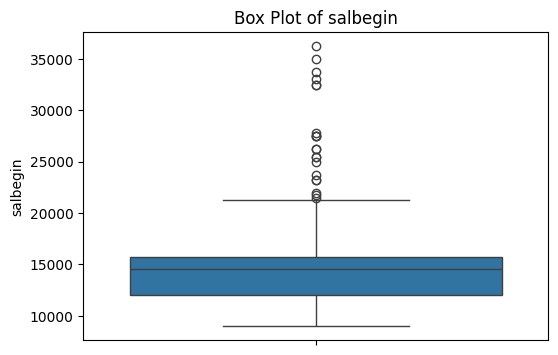

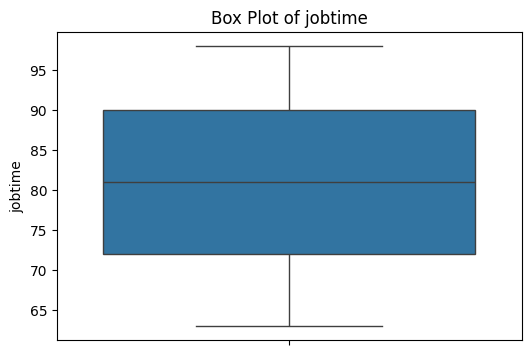

In [35]:
# 6. Box Plot
# -----------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(y=df[col])

    plt.title(f"Box Plot of {col}")

    plt.show()

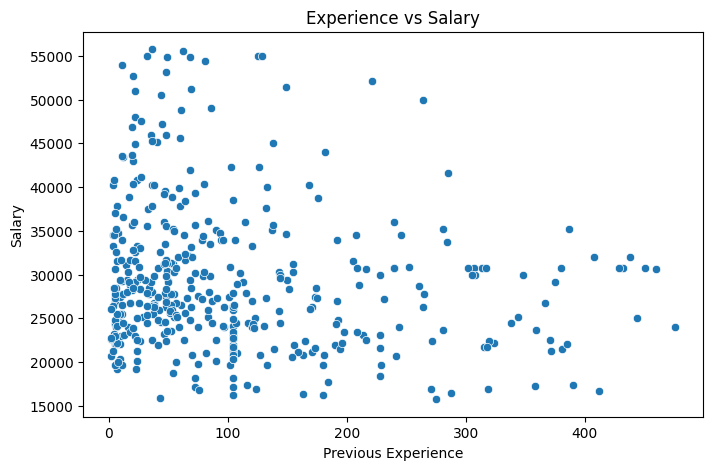

In [36]:
# Convert 'prevexp' to numeric, coercing errors to NaN
df['prevexp'] = pd.to_numeric(df['prevexp'], errors='coerce')

# Fill any new NaNs in 'prevexp' that resulted from coercion with the mean
df['prevexp'] = df['prevexp'].fillna(df['prevexp'].mean())

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='prevexp',
    y='salary',
    data=df
)
plt.title("Experience vs Salary")
plt.xlabel("Previous Experience")
plt.ylabel("Salary")
plt.show()

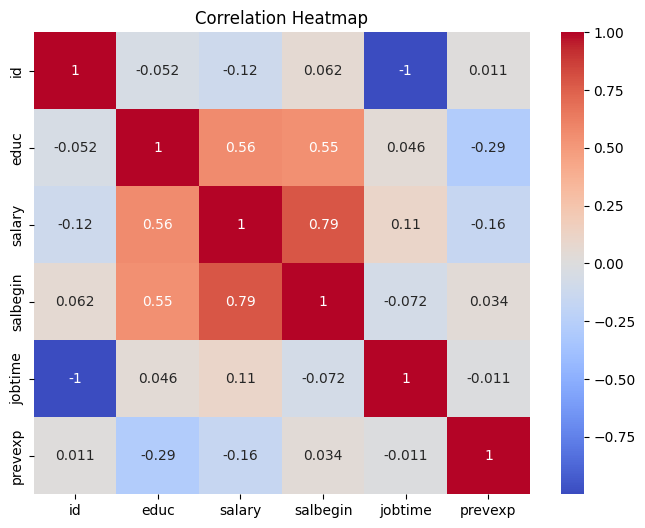

In [37]:
# 7. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


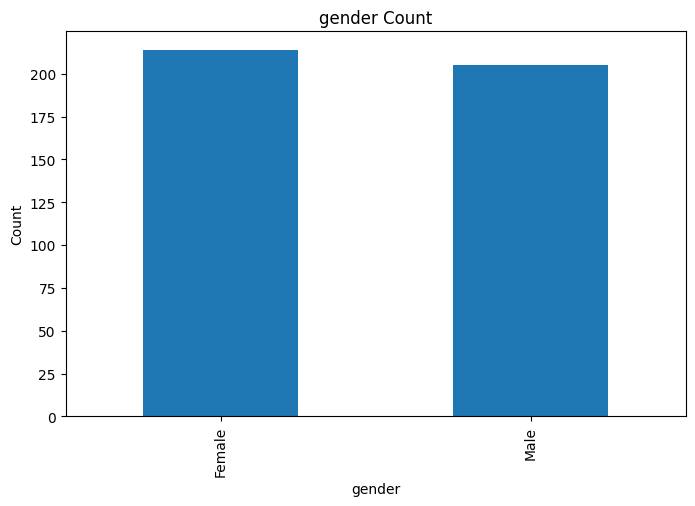

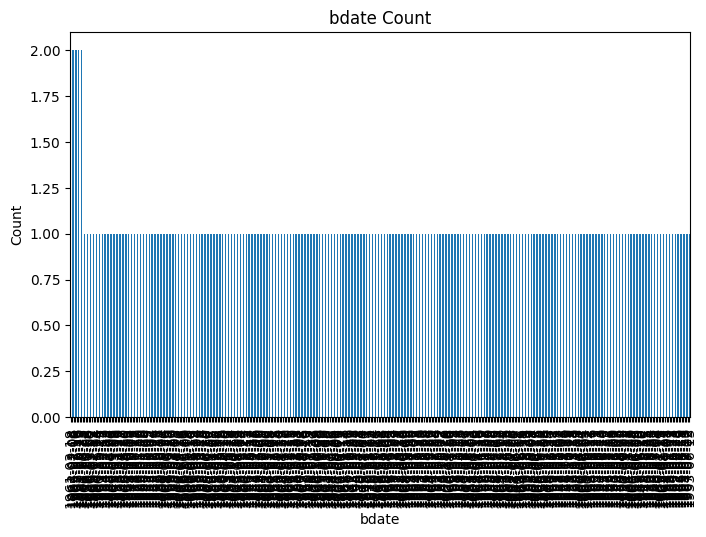

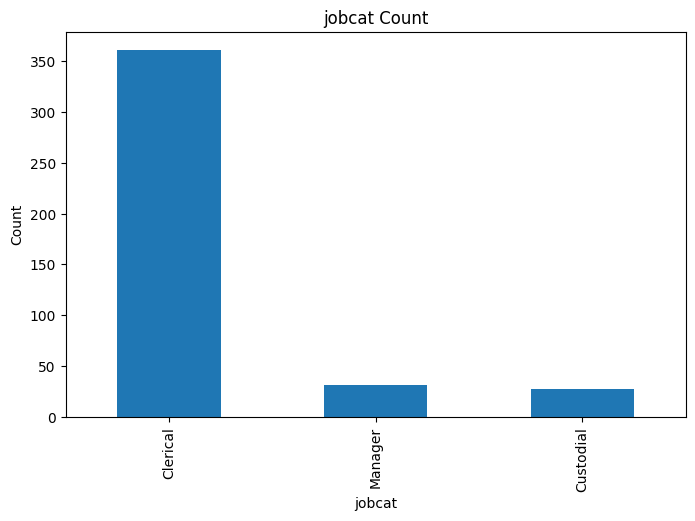

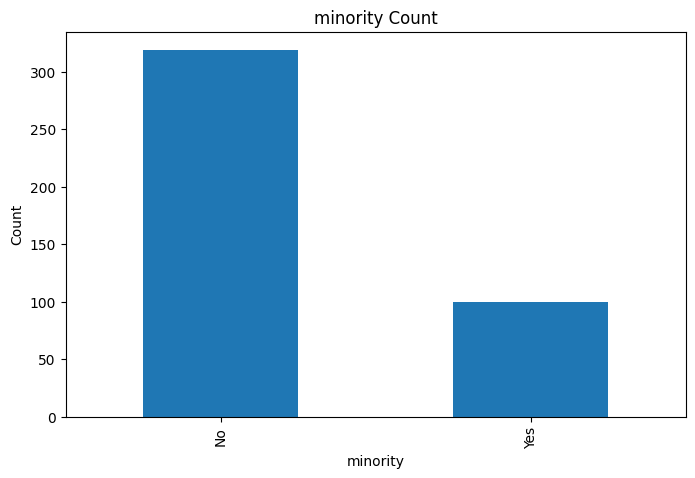

In [38]:
# 8. Bar Charts
# -----------------------------
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    plt.figure(figsize=(8,5))

    df[col].value_counts().plot(kind='bar')

    plt.title(f"{col} Count")

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.show()

## Task 3: Save Cleaned Dataset

In [39]:
# 10. Save Cleaned Dataset
# -----------------------------
df.to_csv("cleaned_employee_data.csv", index=False)

print("\nPROJECT COMPLETED SUCCESSFULLY")
print("Cleaned dataset saved as cleaned_employee_data.csv")


PROJECT COMPLETED SUCCESSFULLY
Cleaned dataset saved as cleaned_employee_data.csv


In [40]:
from google.colab import files

files.download('cleaned_employee_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>